In [3]:
# ================= IMPORTING LIBRARIES ================= #

import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

warnings.filterwarnings('ignore')

# ================= MYSQL CONNECTION ================= #

engine = create_engine(
    "mysql+pymysql://root:@127.0.0.1:3306/inventory_db",
    pool_pre_ping=True,
    pool_recycle=3600
)

print("Libraries imported successfully")
print("MySQL connection established")

Libraries imported successfully
MySQL connection established


In [42]:
from scipy import stats

In [4]:
# ================= FETCHING VENDOR SUMMARY DATA ================= #

df = pd.read_sql_query(
    "SELECT * FROM vendor_sales_summary",
    engine
)

# ================= PREVIEW DATA ================= #

df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05


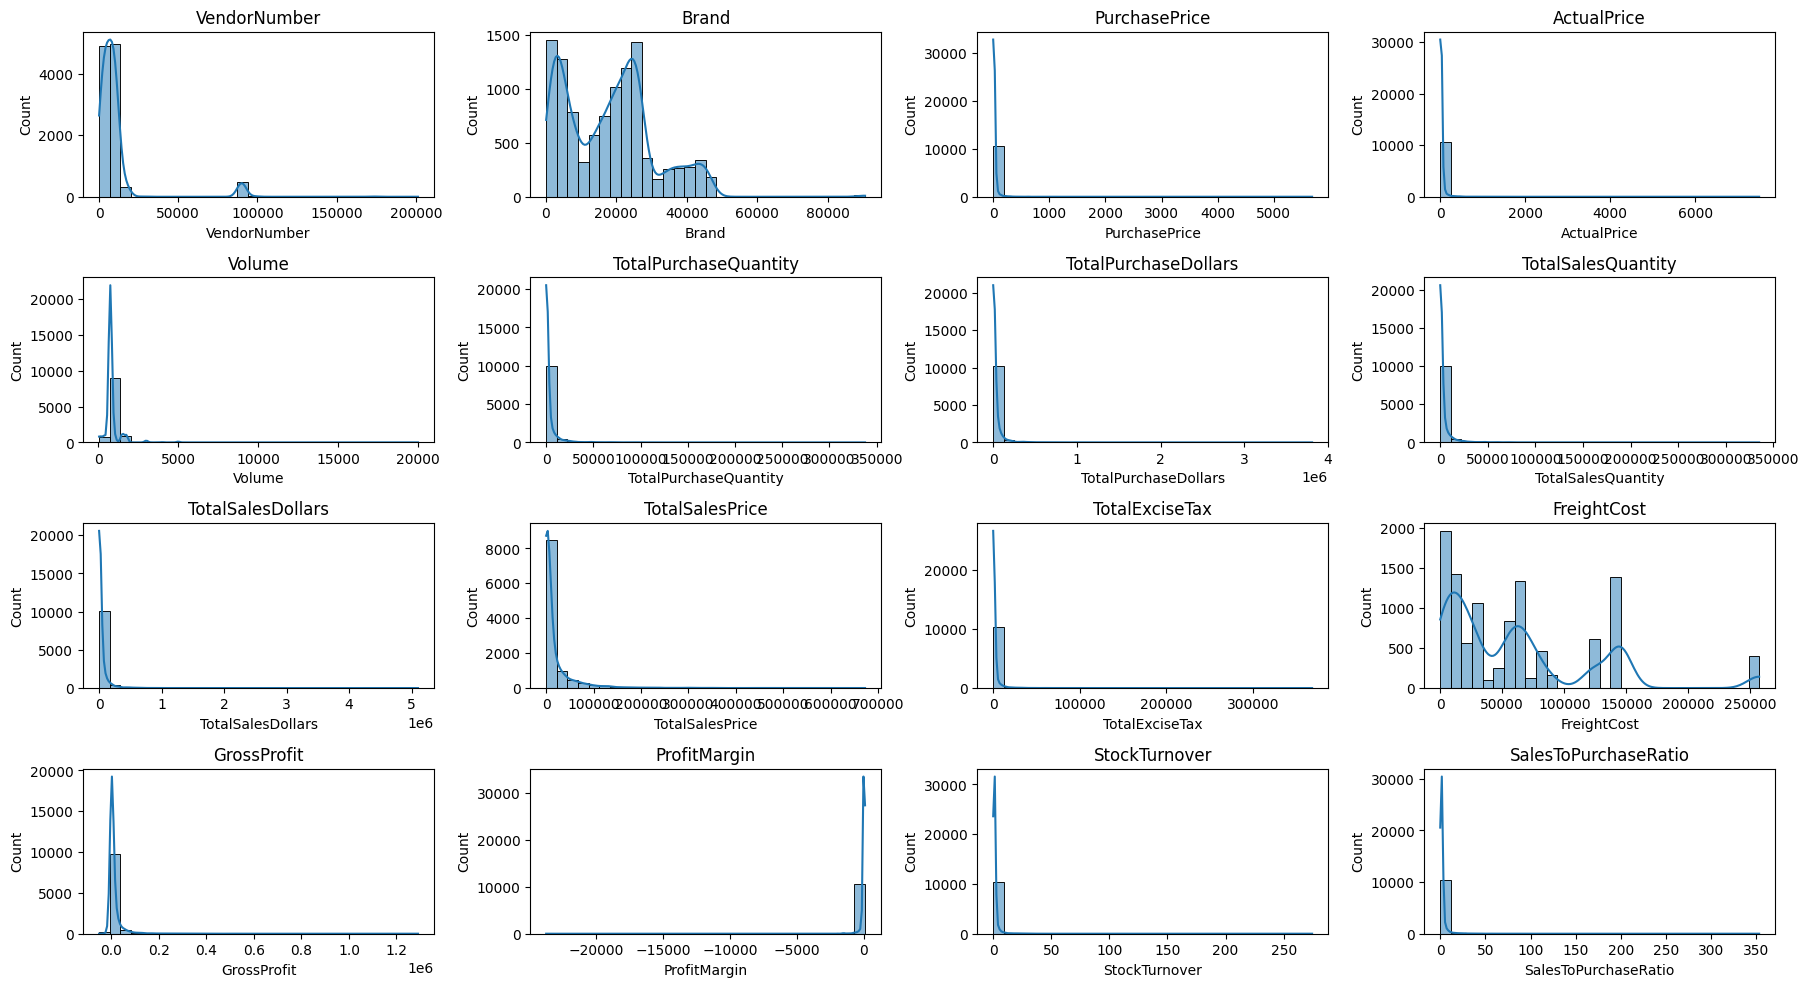

In [6]:
# ================= DISTRIBUTION PLOTS FOR NUMERICAL COLUMNS ================= #

numerical_cols = df.select_dtypes(
    include=np.number
).columns

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_cols):

    plt.subplot(5, 4, i + 1)

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(col)

plt.tight_layout()

plt.show()

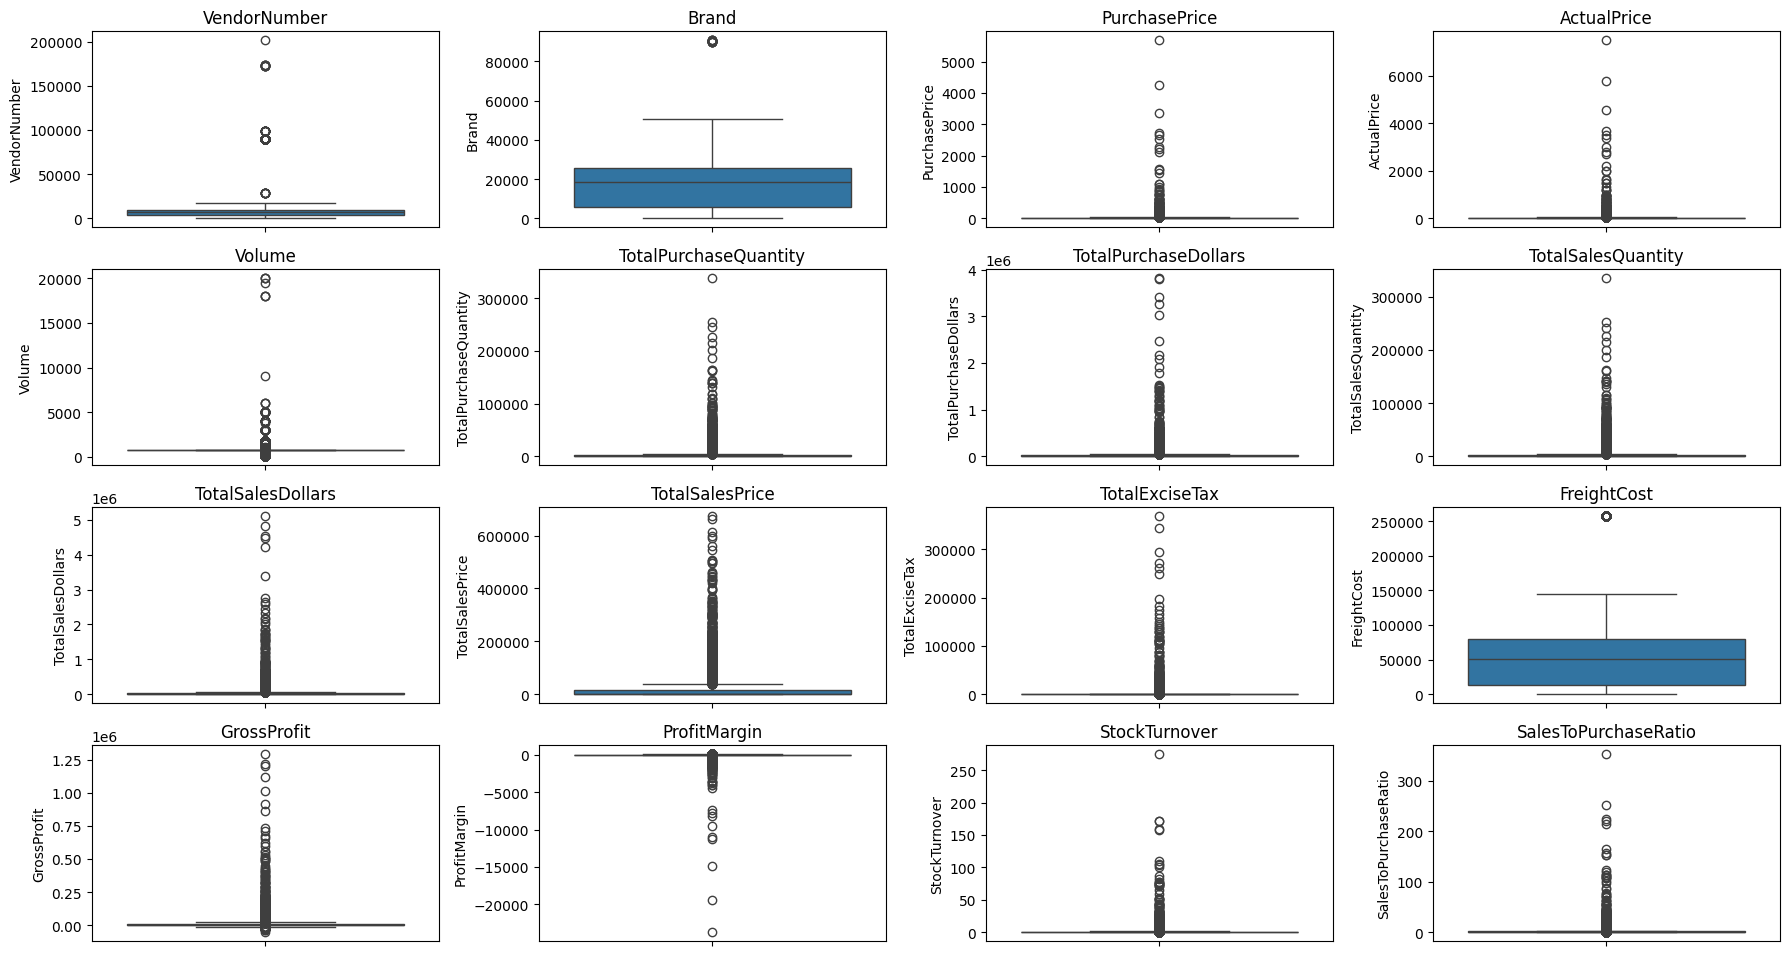

In [7]:
# ================= OUTLIER DETECTION USING BOXPLOTS ================= #

plt.figure(figsize=(18, 12))

for i, col in enumerate(numerical_cols):

    plt.subplot(5, 4, i + 1)

    sns.boxplot(
        y=df[col]
    )

    plt.title(col)

plt.tight_layout()

plt.show()

In [8]:
# ================= FILTERING DATA BY REMOVING INCONSISTENCIES ================= #

df = pd.read_sql_query(
    """
    SELECT *

    FROM vendor_sales_summary

    WHERE GrossProfit > 0
        AND ProfitMargin > 0
        AND TotalSalesQuantity > 0
    """,
    engine
)

# ================= PREVIEW FILTERED DATA ================= #

df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


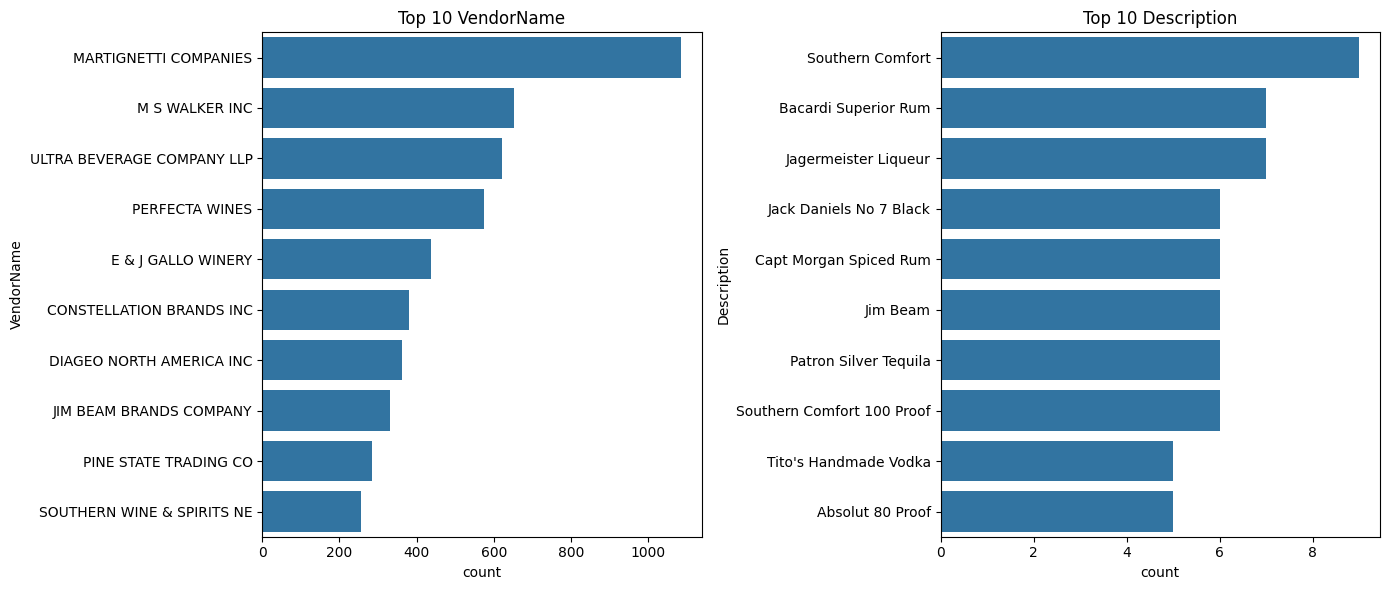

In [9]:
# ================= COUNT PLOTS FOR CATEGORICAL COLUMNS ================= #

categorical_cols = [
    'VendorName',
    'Description'
]

plt.figure(figsize=(14, 6))

for i, col in enumerate(categorical_cols):

    plt.subplot(1, 2, i + 1)

    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10]
    )

    plt.title(f'Top 10 {col}')

plt.tight_layout()

plt.show()

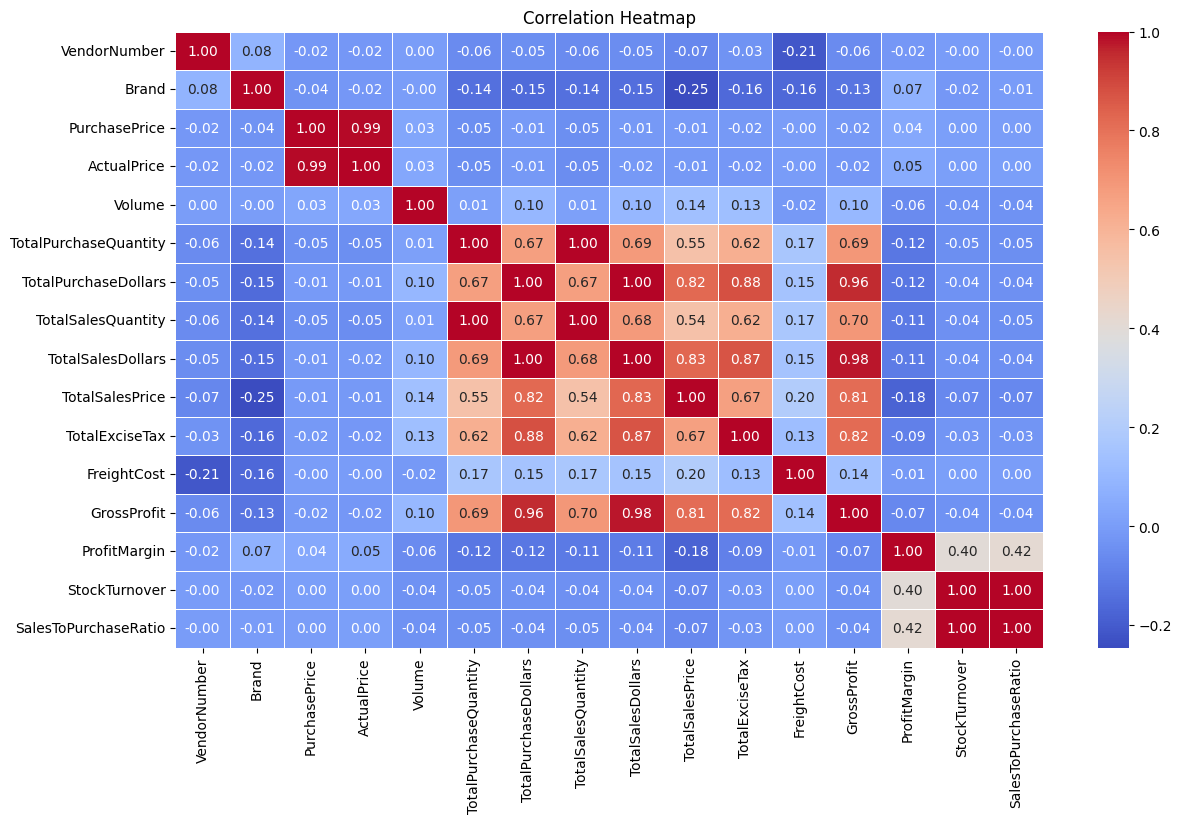

In [10]:
# ================= CORRELATION HEATMAP ================= #

plt.figure(figsize=(14, 8))

correlation_matrix = df[
    numerical_cols
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

In [12]:
# ================= BRAND PERFORMANCE ANALYSIS ================= #

brand_performance = (
    df.groupby('Description')
    .agg({
        'TotalSalesDollars': 'sum',
        'ProfitMargin': 'mean'
    })
    .reset_index()
)

# ================= THRESHOLDS ================= #

low_sales_threshold = (
    brand_performance['TotalSalesDollars']
    .quantile(0.15)
)

high_margin_threshold = (
    brand_performance['ProfitMargin']
    .quantile(0.85)
)

# ================= FILTERING BRANDS ================= #

target_brands = brand_performance[
    (
        brand_performance['TotalSalesDollars']
        < low_sales_threshold
    )
    &
    (
        brand_performance['ProfitMargin']
        > high_margin_threshold
    )
]

# ================= RESULT ================= #

target_brands

,Description,TotalSalesDollars,ProfitMargin
6,12 Days of Pearls Gift Set,309.69,97.678323
45,4 Orange Vodka,483.78,85.902683
57,A Bichot Clos Marechaudes,539.94,67.740860
59,A Bichot Merc Champs M,515.88,94.552997
96,Absolut Orient Apple Vodka,119.94,87.652159
...,...,...,...
7588,Woodford Rsv Master Coll Pnt,489.95,73.760588
7663,Zardetto Pros di Coneg Brut,345.86,88.758457
7677,Zerran Tinto Montsant,139.91,77.592738
7686,Zhenka Vodka 80 Proof,240.39,87.303964


In [14]:
# ================= FILTERING FOR BETTER VISUALIZATION ================= #

brand_performance = brand_performance[
    brand_performance['TotalSalesDollars'] < 10000
]

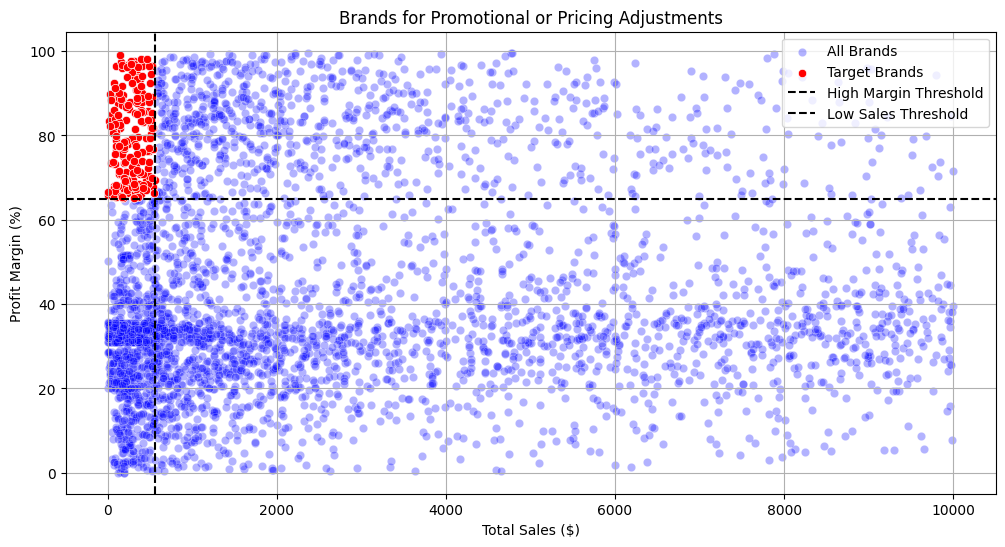

In [15]:
# ================= VISUALIZING TARGET BRANDS ================= #

plt.figure(figsize=(12, 6))

# All Brands
sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.3
)

# Target Brands
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

# Threshold Lines
plt.axhline(
    high_margin_threshold,
    linestyle='--',
    color='black',
    label='High Margin Threshold'
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='black',
    label='Low Sales Threshold'
)

# Labels & Title
plt.xlabel('Total Sales ($)')

plt.ylabel('Profit Margin (%)')

plt.title(
    'Brands for Promotional or Pricing Adjustments'
)

plt.legend()

plt.grid(True)

plt.show()

In [17]:
# ================= FORMAT SALES VALUES ================= #

def format_dollars(value):

    if value >= 1_000_000:

        return f"{value / 1_000_000:.2f}M"

    elif value >= 1_000:

        return f"{value / 1_000:.2f}K"

    else:

        return f"{value:.2f}"

In [18]:
# ================= TOP VENDORS & BRANDS BY SALES PERFORMANCE ================= #

# Top Vendors
top_vendors = (
    df.groupby('VendorName')['TotalSalesDollars']
    .sum()
    .nlargest(10)
)

# Top Brands
top_brands = (
    df.groupby('Description')['TotalSalesDollars']
    .sum()
    .nlargest(10)
)

# ================= RESULTS ================= #

print("Top Vendors by Sales")

display(top_vendors)

print("\nTop Brands by Sales")

display(top_brands)

Top Vendors by Sales


VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.933036e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: TotalSalesDollars, dtype: float64


Top Brands by Sales


Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [19]:
# ================= FORMATTING TOP BRANDS SALES ================= #

top_brands.apply(
    lambda x: format_dollars(x)
)

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

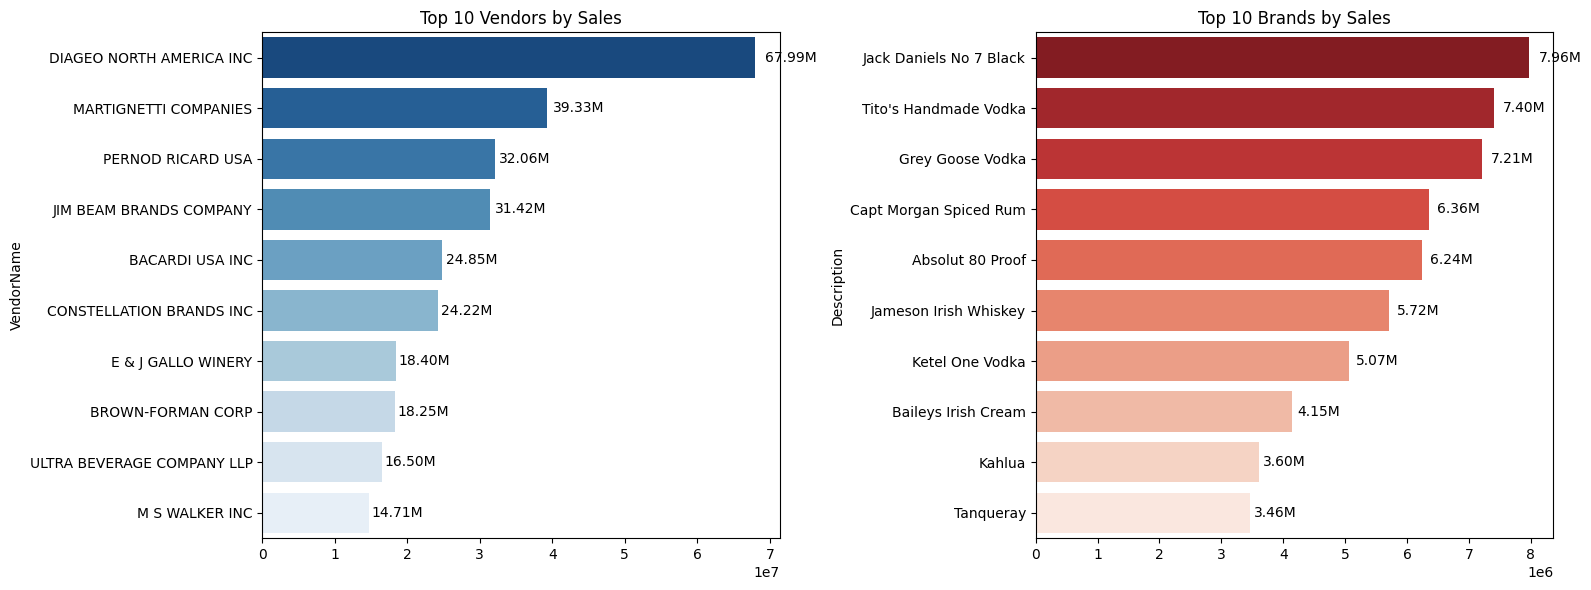

In [20]:
# ================= VISUALIZING TOP VENDORS & BRANDS ================= #

plt.figure(figsize=(16, 6))

# ================= TOP VENDORS ================= #

plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    palette='Blues_r'
)

plt.title('Top 10 Vendors by Sales')

# Add value labels
for bar in ax1.patches:

    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),

        bar.get_y() + bar.get_height() / 2,

        format_dollars(bar.get_width()),

        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# ================= TOP BRANDS ================= #

plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    palette='Reds_r'
)

plt.title('Top 10 Brands by Sales')

# Add value labels
for bar in ax2.patches:

    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),

        bar.get_y() + bar.get_height() / 2,

        format_dollars(bar.get_width()),

        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()

plt.show()

In [21]:
# ================= VENDOR PURCHASE PERFORMANCE ================= #

vendor_performance = (
    df.groupby('VendorName')
    .agg({
        'TotalPurchaseDollars': 'sum',
        'GrossProfit': 'sum',
        'TotalSalesDollars': 'sum'
    })
    .reset_index()
)

# ================= PURCHASE CONTRIBUTION % ================= #

vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars']
    / vendor_performance['TotalPurchaseDollars'].sum()
) * 100

# ================= PREVIEW ================= #

vendor_performance.head()

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53,0.000145
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94,0.008361
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81,0.003809
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16,0.000304
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53,0.033981


In [23]:
# ================= SORTING VENDORS BY PURCHASE CONTRIBUTION ================= #

vendor_performance = vendor_performance.sort_values(
    by='PurchaseContribution%',
    ascending=False
)

# ================= PREVIEW ================= #

vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,1.789287e+07,6.799010e+07,16.300334
57,MARTIGNETTI COMPANIES,25502095.83,1.382826e+07,3.933036e+07,8.297719
68,PERNOD RICARD USA,23851164.17,8.212032e+06,3.206320e+07,7.760548
46,JIM BEAM BRANDS COMPANY,23494304.32,7.928716e+06,3.142302e+07,7.644435
6,BACARDI USA INC,17432020.26,7.422797e+06,2.485482e+07,5.671926
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,1.989500e+02,3.275900e+02,0.000042
107,UNCORKED,118.74,5.820000e+01,1.769400e+02,0.000039
85,SILVER MOUNTAIN CIDERS,77.18,2.653300e+02,3.425100e+02,0.000025
16,CAPSTONE INTERNATIONAL,54.64,1.922300e+02,2.468700e+02,0.000018


In [24]:
# ================= DISPLAY TOP 10 VENDORS ================= #

top_vendors = vendor_performance.head(10).copy()

# Format columns
top_vendors['TotalSalesDollars'] = (
    top_vendors['TotalSalesDollars']
    .apply(format_dollars)
)

top_vendors['TotalPurchaseDollars'] = (
    top_vendors['TotalPurchaseDollars']
    .apply(format_dollars)
)

top_vendors['GrossProfit'] = (
    top_vendors['GrossProfit']
    .apply(format_dollars)
)

# ================= RESULT ================= #

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.300334
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.297719
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.760548
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.644435
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.671926
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.969667
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.307606
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.926789
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.633478
53,M S WALKER INC,9.76M,4.94M,14.71M,3.177053


In [25]:
# ================= CUMULATIVE CONTRIBUTION % ================= #

top_vendors['Cumulative_Contribution%'] = (
    top_vendors['PurchaseContribution%']
    .cumsum()
)

# ================= RESULT ================= #

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.300334,16.300334
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.297719,24.598053
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.760548,32.358601
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.644435,40.003037
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.671926,45.674962
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.969667,50.644630
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.307606,54.952236
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.926789,58.879025
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.633478,62.512503
53,M S WALKER INC,9.76M,4.94M,14.71M,3.177053,65.689556


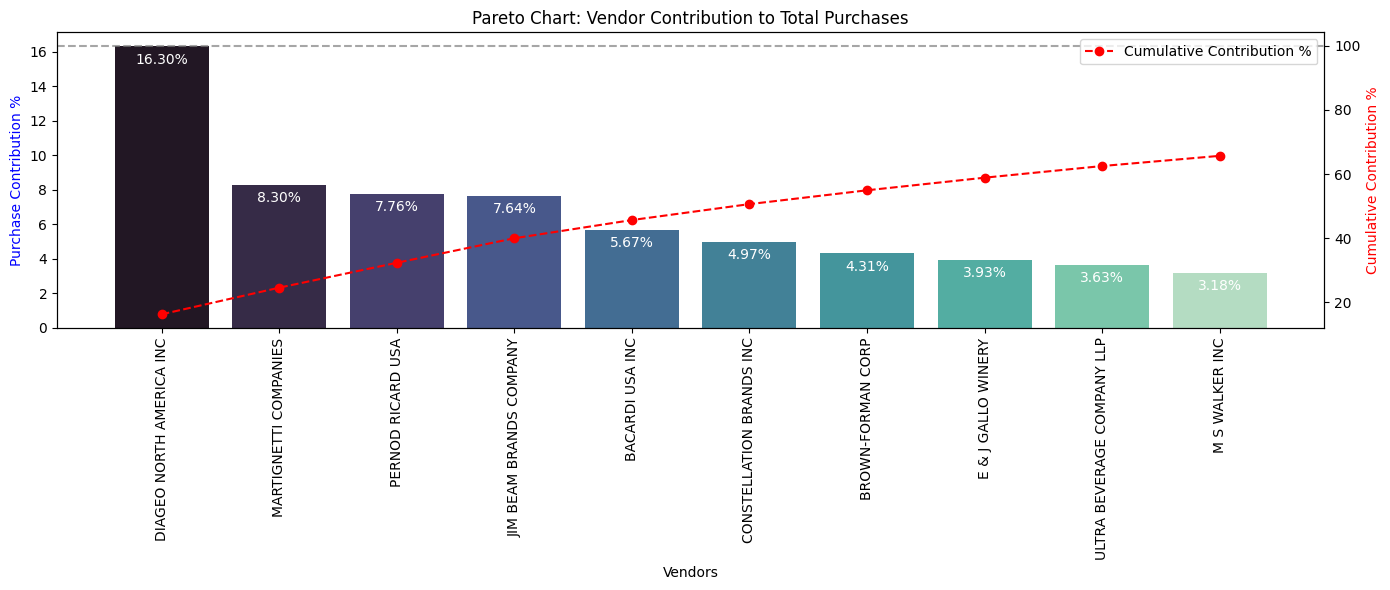

In [26]:
# ================= PARETO CHART : VENDOR CONTRIBUTION ================= #

fig, ax1 = plt.subplots(figsize=(14, 6))

# ================= BAR PLOT ================= #

sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette='mako',
    ax=ax1
)

# Add value labels
for i, value in enumerate(top_vendors['PurchaseContribution%']):

    ax1.text(
        i,
        value - 1,
        f"{value:.2f}%",
        ha='center',
        fontsize=10,
        color='white'
    )

# ================= LINE PLOT ================= #

ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

# ================= LABELS & TITLES ================= #

ax1.set_xticklabels(
    top_vendors['VendorName'],
    rotation=90
)

ax1.set_ylabel(
    'Purchase Contribution %',
    color='blue'
)

ax2.set_ylabel(
    'Cumulative Contribution %',
    color='red'
)

ax1.set_xlabel('Vendors')

ax1.set_title(
    'Pareto Chart: Vendor Contribution to Total Purchases'
)

# 100% reference line
ax2.axhline(
    y=100,
    color='gray',
    linestyle='dashed',
    alpha=0.7
)

ax2.legend(loc='upper right')

plt.tight_layout()

plt.show()

Total Purchase Contribution of Top 10 Vendors is 65.69 %


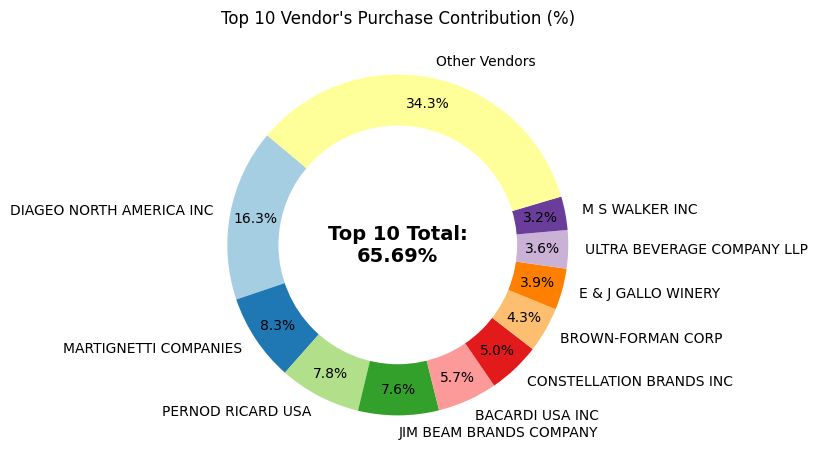

In [27]:
# ================= TOTAL CONTRIBUTION OF TOP 10 VENDORS ================= #

print(
    f"Total Purchase Contribution of Top 10 Vendors is "
    f"{round(top_vendors['PurchaseContribution%'].sum(), 2)} %"
)

# ================= PREPARING DATA FOR DONUT CHART ================= #

vendors = list(
    top_vendors['VendorName'].values
)

purchase_contributions = list(
    top_vendors['PurchaseContribution%'].values
)

total_contribution = sum(
    purchase_contributions
)

remaining_contribution = (
    100 - total_contribution
)

# Add remaining vendors
vendors.append('Other Vendors')

purchase_contributions.append(
    remaining_contribution
)

# ================= DONUT CHART ================= #

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Create donut effect
centre_circle = plt.Circle(
    (0, 0),
    0.70,
    fc='white'
)

fig.gca().add_artist(
    centre_circle
)

# Center text
plt.text(
    0,
    0,

    f"Top 10 Total:\n{total_contribution:.2f}%",

    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title(
    "Top 10 Vendor's Purchase Contribution (%)"
)

plt.tight_layout()

plt.show()

In [28]:
# ================= UNIT PURCHASE PRICE ================= #

df['UnitPurchasePrice'] = np.where(
    df['TotalPurchaseQuantity'] != 0,

    df['TotalPurchaseDollars']
    / df['TotalPurchaseQuantity'],

    0
)

# ================= PREVIEW ================= #

df[['TotalPurchaseDollars',
    'TotalPurchaseQuantity',
    'UnitPurchasePrice']].head()

,TotalPurchaseDollars,TotalPurchaseQuantity,UnitPurchasePrice
0,3811251.60,145080.0,26.27
1,3804041.22,164038.0,23.19
2,3418303.68,187407.0,18.24
3,3261197.94,201682.0,16.17
4,3023206.01,138109.0,21.89


In [29]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080.0,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038.0,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407.0,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682.0,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109.0,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2.0,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6.0,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2.0,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1.0,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [30]:
# ================= CATEGORIZING ORDER SIZE ================= #

df['OrderSize'] = pd.qcut(
    df['TotalPurchaseQuantity'],
    q=3,
    labels=['Small', 'Medium', 'Large']
)

# ================= PREVIEW ================= #

df[['TotalPurchaseQuantity', 'OrderSize']].head()

,TotalPurchaseQuantity,OrderSize
0,145080.0,Large
1,164038.0,Large
2,187407.0,Large
3,201682.0,Large
4,138109.0,Large


In [31]:
# ================= AVERAGE UNIT PURCHASE PRICE BY ORDER SIZE ================= #

df.groupby('OrderSize')[['UnitPurchasePrice']].mean()


,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


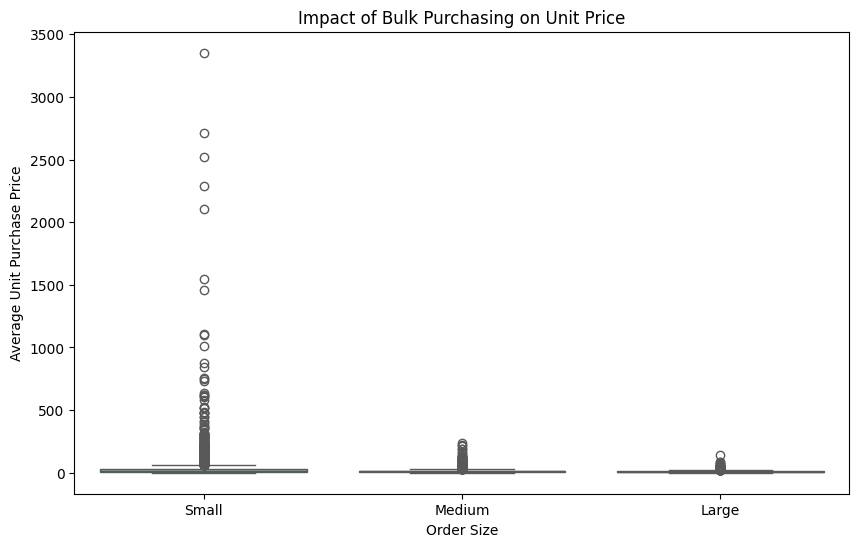

In [32]:
# ================= IMPACT OF BULK PURCHASING ON UNIT PRICE ================= #

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='OrderSize',
    y='UnitPurchasePrice',
    palette='Set2'
)

plt.title(
    'Impact of Bulk Purchasing on Unit Price'
)

plt.xlabel('Order Size')

plt.ylabel('Average Unit Purchase Price')

plt.show()

In [36]:
# ================= TOP 10 LOW STOCK TURNOVER VENDORS ================= #

low_stock_turnover = (
    df[df['StockTurnover'] < 1]
    .groupby('VendorName')[['StockTurnover']]
    .mean()
    .sort_values(
        by='StockTurnover',
        ascending=True
    )
    .head(10)
)

# ================= RESULT ================= #

low_stock_turnover

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


In [37]:
# ================= UNSOLD INVENTORY VALUE ================= #

df['UnsoldInventoryValue'] = (
    (
        df['TotalPurchaseQuantity']
        - df['TotalSalesQuantity']
    )
    * df['PurchasePrice']
)

# ================= TOTAL UNSOLD CAPITAL ================= #

print(
    'Total Unsold Capital:',
    format_dollars(
        df['UnsoldInventoryValue'].sum()
    )
)

Total Unsold Capital: 2.71M


In [38]:
# ================= CAPITAL LOCKED PER VENDOR ================= #

inventory_value_per_vendor = (
    df.groupby('VendorName')['UnsoldInventoryValue']
    .sum()
    .reset_index()
)

# ================= SORTING VENDORS ================= #

inventory_value_per_vendor = (
    inventory_value_per_vendor
    .sort_values(
        by='UnsoldInventoryValue',
        ascending=False
    )
)

# ================= FORMAT VALUES ================= #

inventory_value_per_vendor[
    'UnsoldInventoryValue'
] = (
    inventory_value_per_vendor[
        'UnsoldInventoryValue'
    ].apply(format_dollars)
)

# ================= TOP 10 VENDORS ================= #

inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


In [39]:
# ================= SALES THRESHOLDS ================= #

top_threshold = (
    df['TotalSalesDollars']
    .quantile(0.75)
)

low_threshold = (
    df['TotalSalesDollars']
    .quantile(0.25)
)

# ================= TOP & LOW VENDORS ================= #

top_vendors = (
    df[
        df['TotalSalesDollars'] >= top_threshold
    ]['ProfitMargin']
    .dropna()
)

low_vendors = (
    df[
        df['TotalSalesDollars'] <= low_threshold
    ]['ProfitMargin']
    .dropna()
)

# ================= PREVIEW ================= #

top_vendors.head()

0    25.297693
1    21.062810
2    24.675786
3    27.139908
4    28.412764
Name: ProfitMargin, dtype: float64

In [40]:
# ================= CONFIDENCE INTERVAL FUNCTION ================= #

def confidence_interval(data, confidence=0.95):

    mean_val = np.mean(data)

    std_err = (
        np.std(data, ddof=1)
        / np.sqrt(len(data))
    )

    t_critical = stats.t.ppf(
        (1 + confidence) / 2,
        df=len(data) - 1
    )

    margin_of_error = (
        t_critical * std_err
    )

    return (
        mean_val,
        mean_val - margin_of_error,
        mean_val + margin_of_error
    )

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


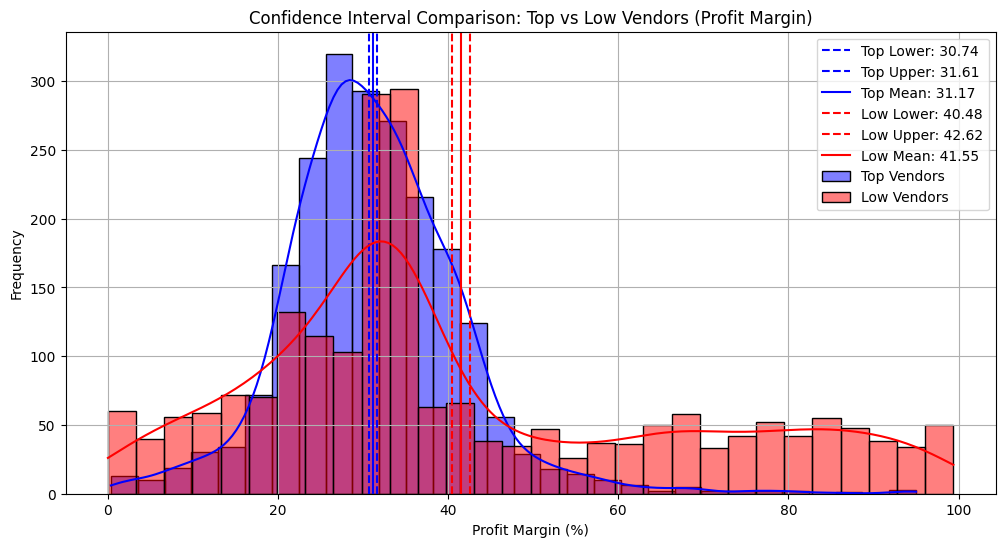

In [43]:
# ================= CONFIDENCE INTERVAL ANALYSIS ================= #

top_mean, top_lower, top_upper = confidence_interval(
    top_vendors
)

low_mean, low_lower, low_upper = confidence_interval(
    low_vendors
)

# ================= PRINT RESULTS ================= #

print(
    f"Top Vendors 95% CI: "
    f"({top_lower:.2f}, {top_upper:.2f}), "
    f"Mean: {top_mean:.2f}"
)

print(
    f"Low Vendors 95% CI: "
    f"({low_lower:.2f}, {low_upper:.2f}), "
    f"Mean: {low_mean:.2f}"
)

# ================= VISUALIZATION ================= #

plt.figure(figsize=(12, 6))

# ---------- TOP VENDORS ---------- #

sns.histplot(
    top_vendors,
    kde=True,
    color='blue',
    bins=30,
    alpha=0.5,
    label='Top Vendors'
)

plt.axvline(
    top_lower,
    color='blue',
    linestyle='--',
    label=f"Top Lower: {top_lower:.2f}"
)

plt.axvline(
    top_upper,
    color='blue',
    linestyle='--',
    label=f"Top Upper: {top_upper:.2f}"
)

plt.axvline(
    top_mean,
    color='blue',
    linestyle='-',
    label=f"Top Mean: {top_mean:.2f}"
)

# ---------- LOW VENDORS ---------- #

sns.histplot(
    low_vendors,
    kde=True,
    color='red',
    bins=30,
    alpha=0.5,
    label='Low Vendors'
)

plt.axvline(
    low_lower,
    color='red',
    linestyle='--',
    label=f"Low Lower: {low_lower:.2f}"
)

plt.axvline(
    low_upper,
    color='red',
    linestyle='--',
    label=f"Low Upper: {low_upper:.2f}"
)

plt.axvline(
    low_mean,
    color='red',
    linestyle='-',
    label=f"Low Mean: {low_mean:.2f}"
)

# ================= FINALIZE PLOT ================= #

plt.title(
    'Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)'
)

plt.xlabel('Profit Margin (%)')

plt.ylabel('Frequency')

plt.legend()

plt.grid(True)

plt.show()